# 03 · Visualization

Generates every named figure in *"Public Trust and Geo Spatial Resilience"* from the processed panel and ABS data, and saves each as a 300dpi PNG + vector PDF under `figures/`. This is a thin, narrated wrapper around `src/visualization.py` — function names mirror the paper's own figure labels so the paper-figure <-> code mapping stays traceable (see the project `README.md` for the full figure/paper-section map).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config, visualization
from src.utils import ensure_dir, setup_logging

logger = setup_logging()
ensure_dir(config.FIGURES_DIR)

panel = pd.read_csv(config.PANEL_CSV)
abs_df = pd.read_csv(config.ABS_CSV)

## Figure A — Worldwide Governance Indicators
Nepal vs. South Asia, 1996-2024. Section 2 / Section 5.1-5.2.

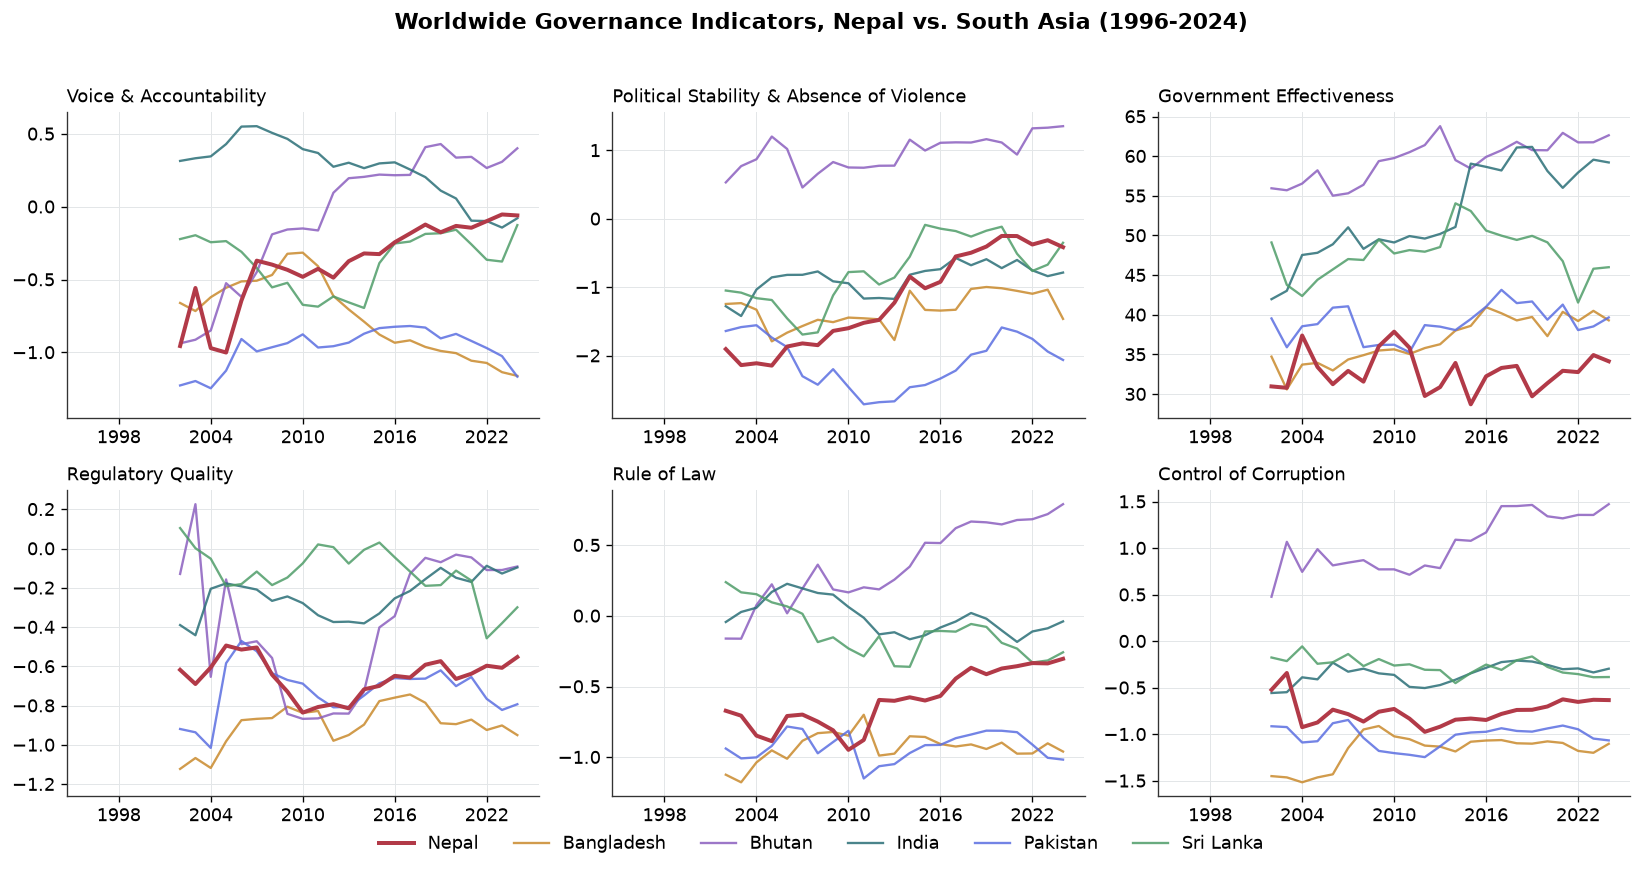

In [2]:
visualization.figure_a_governance_trends(panel)
plt.show()

## Figure A2 — V-Dem governance & civic-space trends

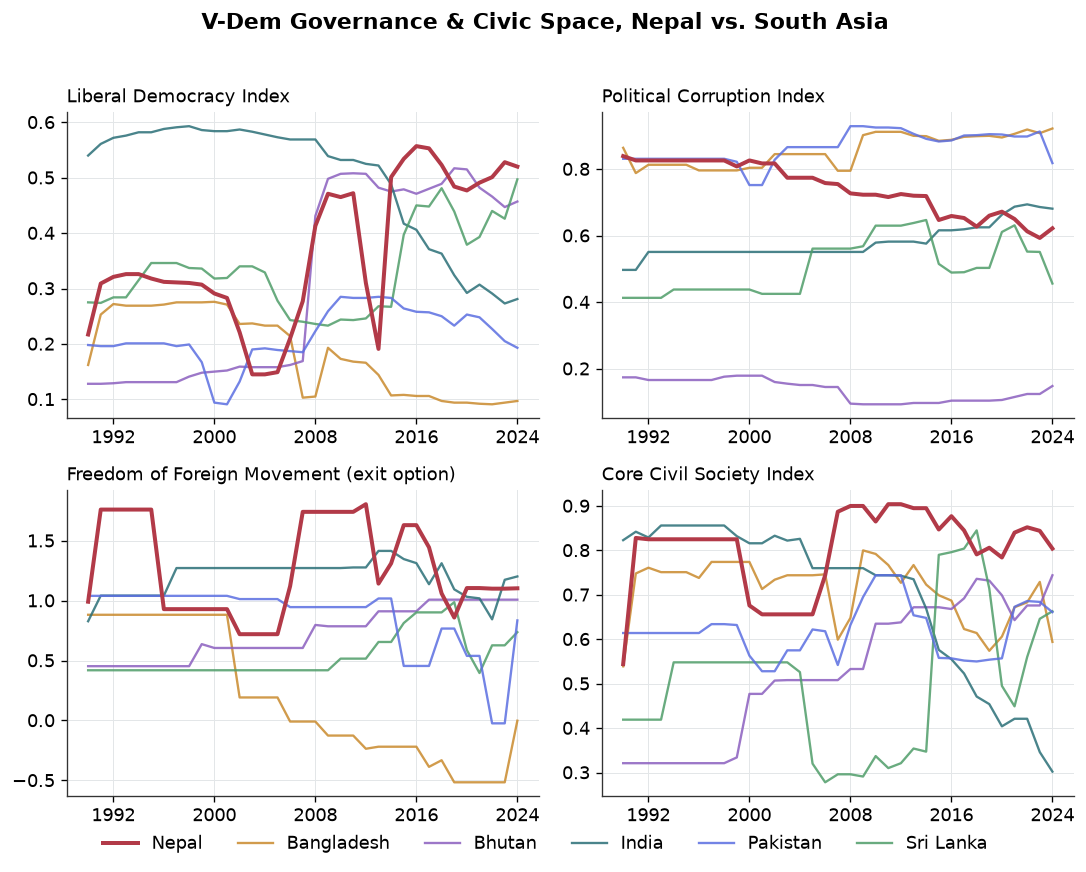

In [3]:
visualization.figure_a2_vdem_trends(panel)
plt.show()

## Figure G — Democratic Resilience (V-Dem Regimes of the World)
Fig. 2's own terminal node. Section 5.7 / Table 1.

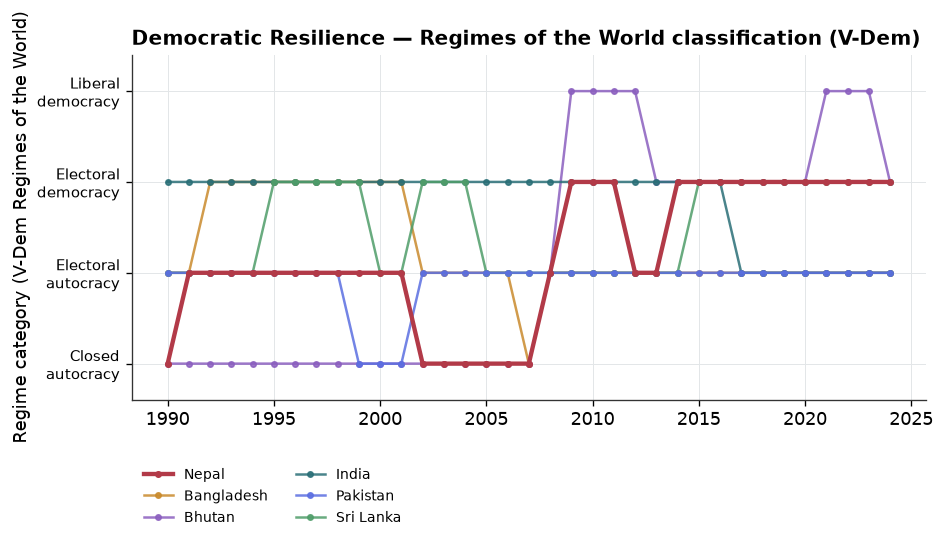

In [4]:
visualization.figure_g_democratic_resilience(panel)
plt.show()

## Figure C — Socio-economic trends

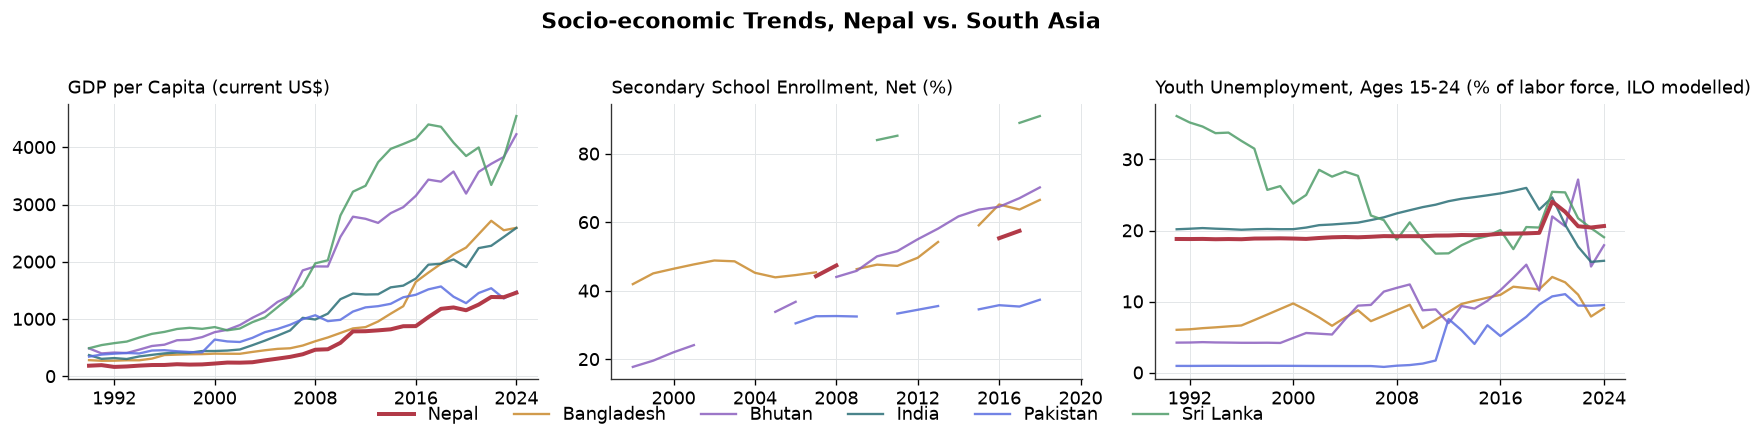

In [5]:
visualization.figure_c_socioeconomic_trends(panel)
plt.show()

## Figure B — Migration & remittance trends

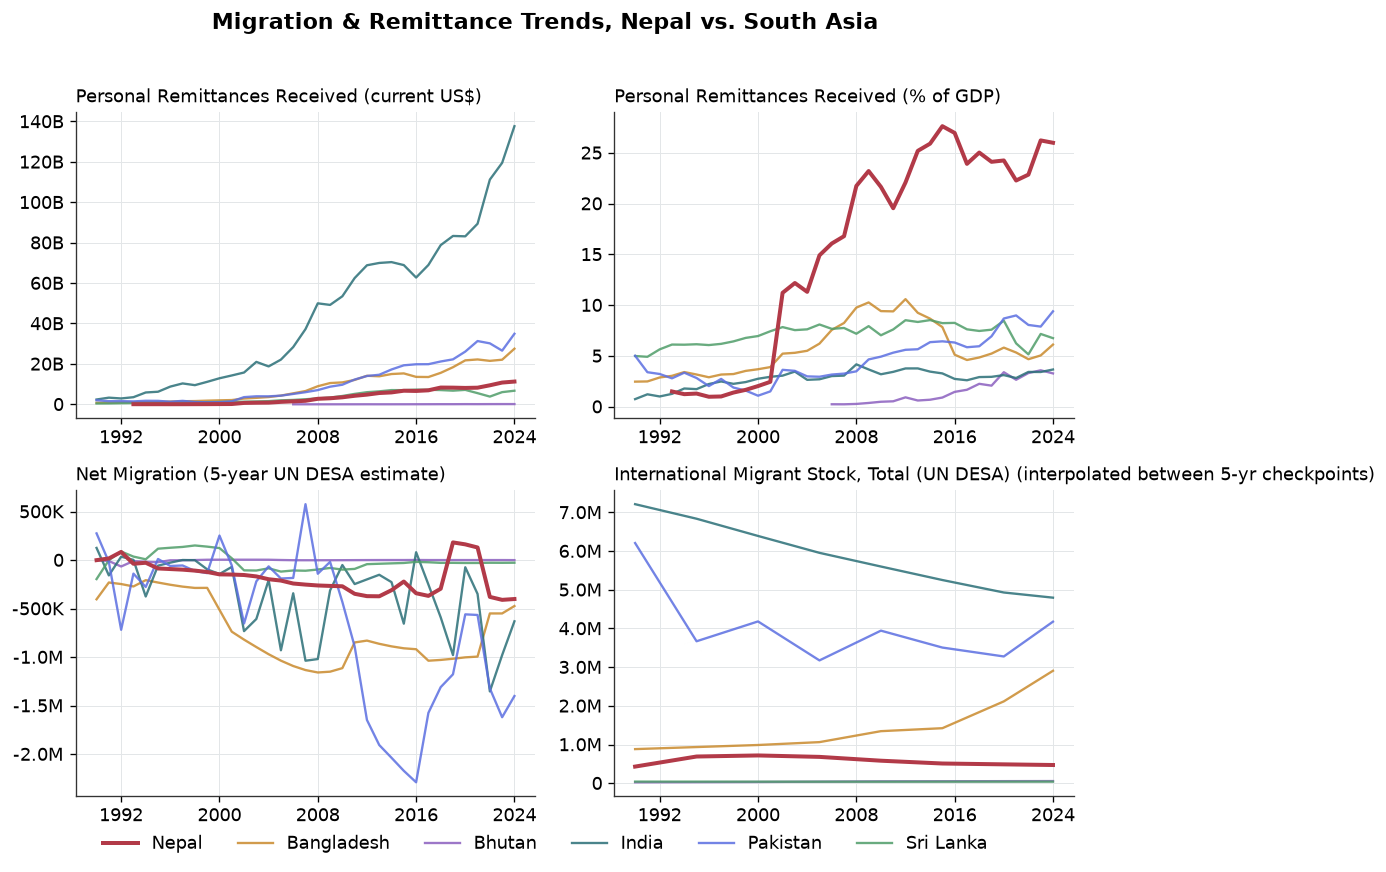

In [6]:
visualization.figure_b_migration_trends(panel)
plt.show()

## Figure D — Nepal correlation heatmap
Exit, governance & migration-proxy co-movement.

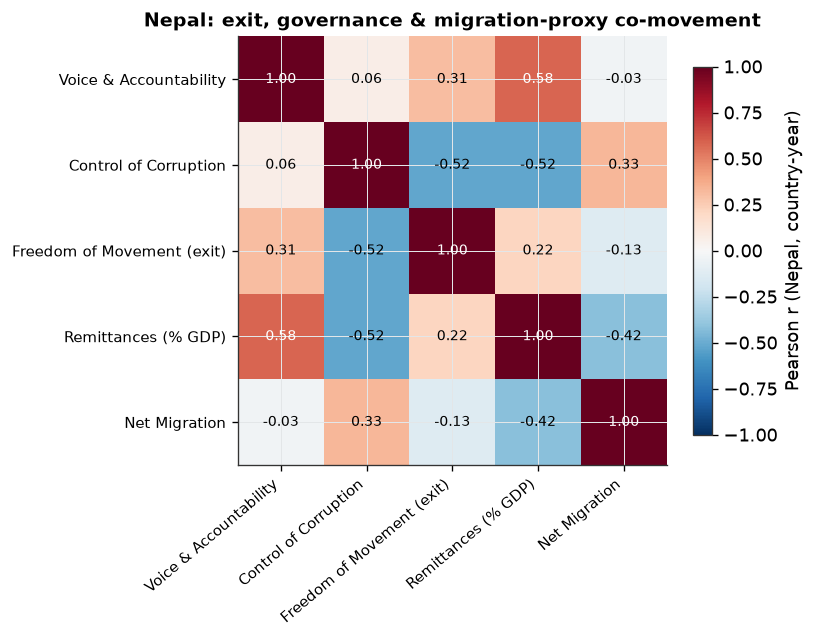

,Voice & Accountability,Control of Corruption,Freedom of Movement (exit),Remittances (% GDP),Net Migration
Voice & Accountability,1.00,0.06,0.31,0.58,-0.03
Control of Corruption,0.06,1.00,-0.52,-0.52,0.33
Freedom of Movement (exit),0.31,-0.52,1.00,0.22,-0.13
Remittances (% GDP),0.58,-0.52,0.22,1.00,-0.42
Net Migration,-0.03,0.33,-0.13,-0.42,1.00


In [7]:
fig_d, corr_display = visualization.figure_d_correlation_heatmap(panel)
plt.show()
corr_display.round(2)

## Figure E — Nepal remittances forecast
Observed + 3 forecasts + backtest. Quote the linear-trend R², not the 2029 endpoint.

/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starti

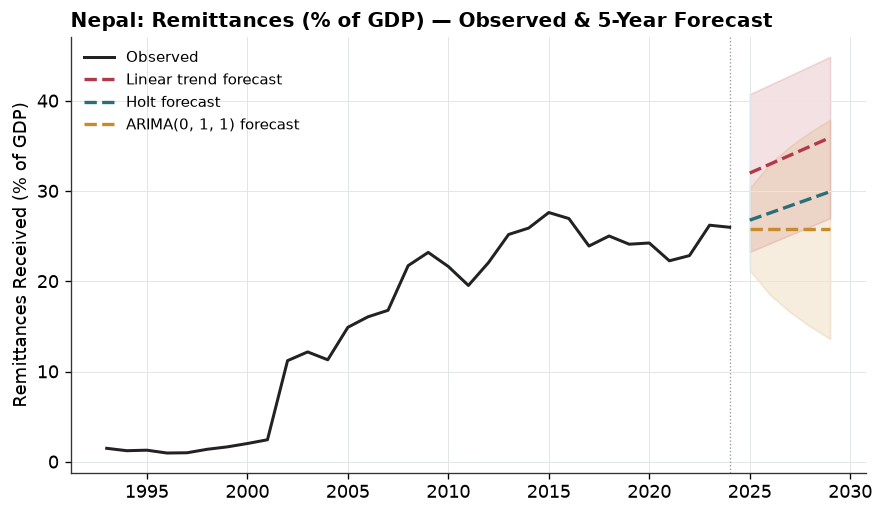

In [8]:
fig_e, remittances_results = visualization.figure_e_remittances_forecast(panel)
plt.show()

## Figure F — Nepal governance forecast

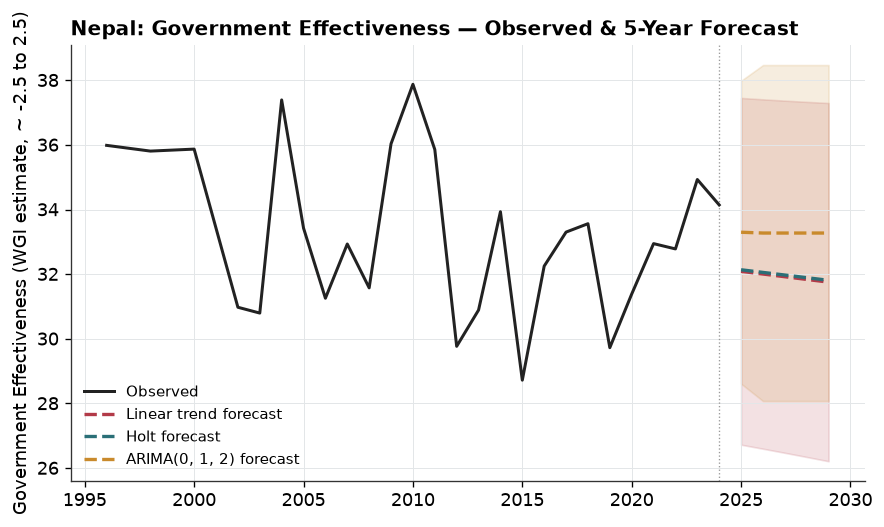

In [9]:
fig_f, governance_results = visualization.figure_f_governance_forecast(panel)
plt.show()

## ABS trust-by-wave figure
Institutional trust by country, 2005 vs. 2013.

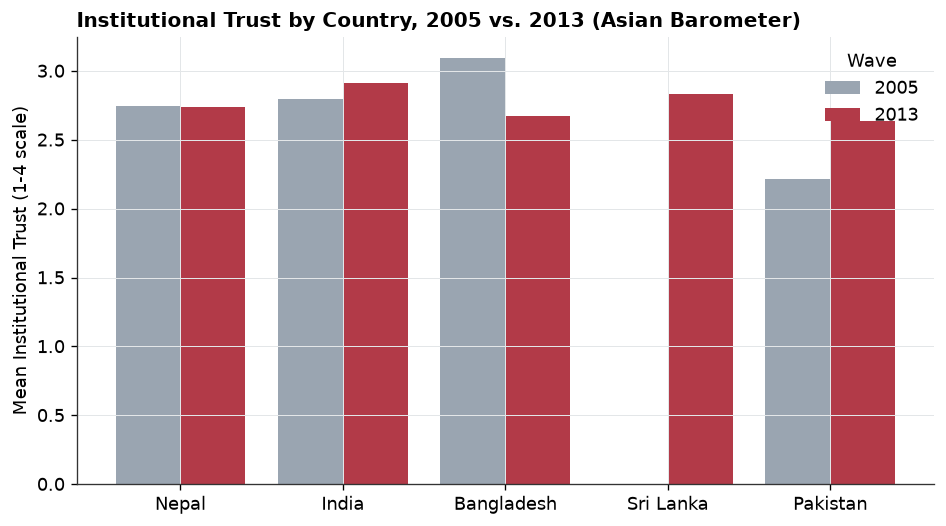

In [10]:
visualization.figure_abs_trust_wave(abs_df)
plt.show()

## ABS institution-level trust figures

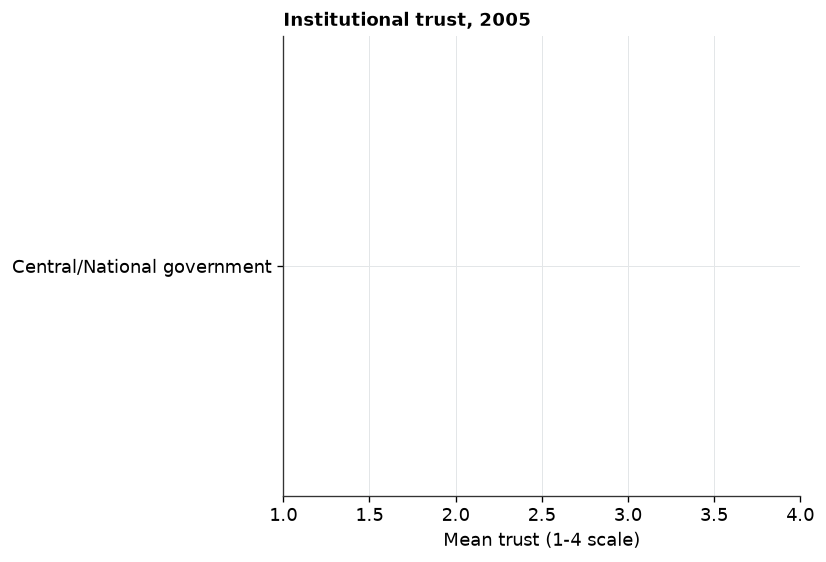

In [11]:
visualization.figure_abs_trust_by_institution(
    abs_df, "2005", config.WAVE1_TRUST_ITEMS, config.WAVE1_TRUST_LABELS
)
plt.show()

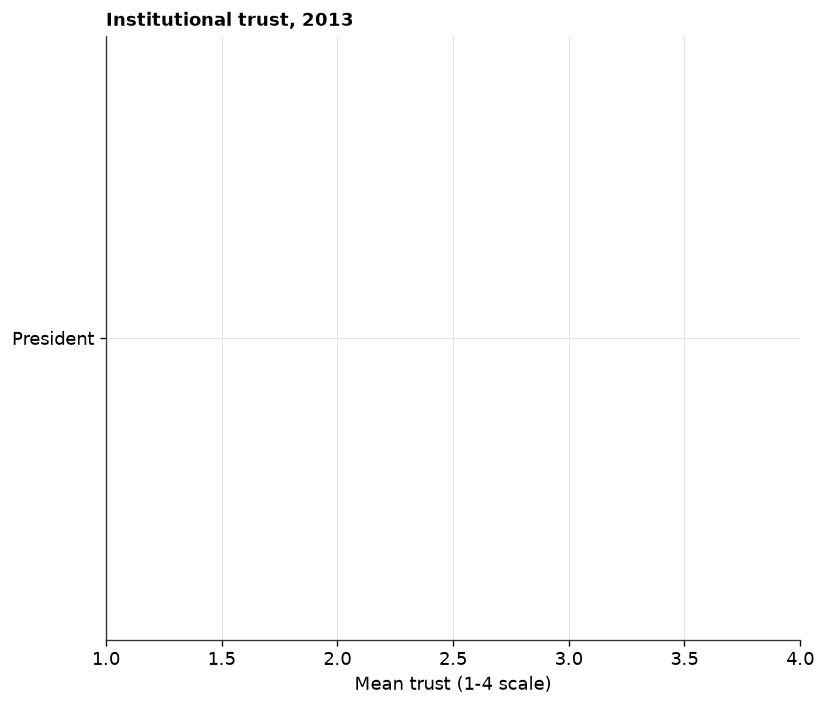

In [12]:
visualization.figure_abs_trust_by_institution(
    abs_df, "2013", config.WAVE2_TRUST_ITEMS, config.WAVE2_TRUST_LABELS
)
plt.show()

## ABS regime-preference-by-wave figure

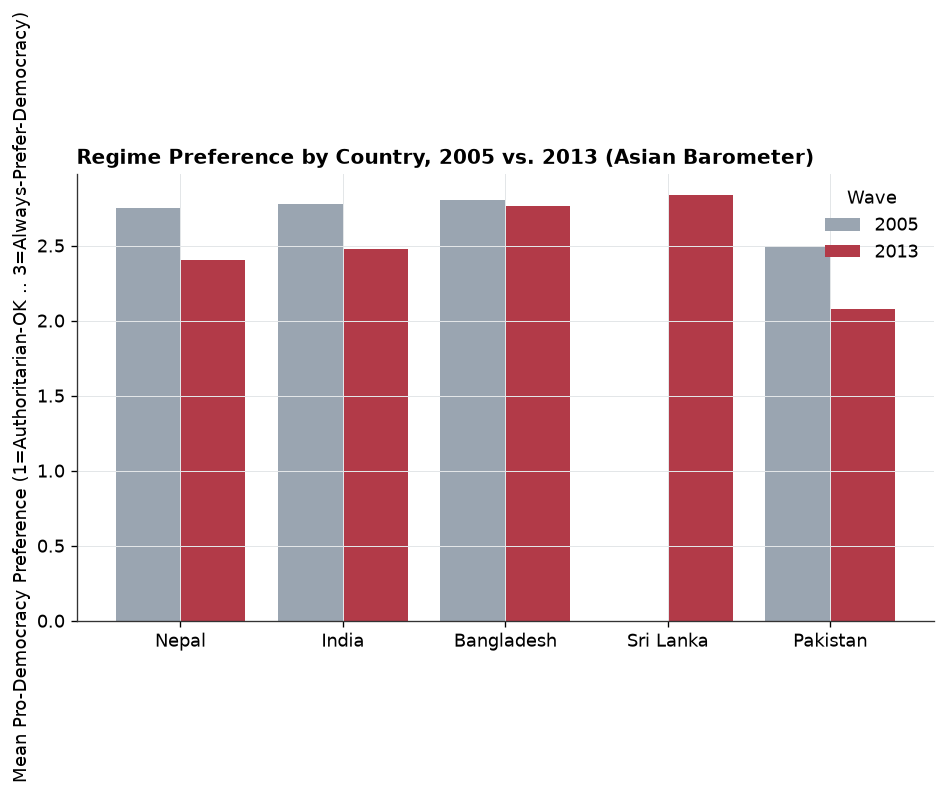

In [13]:
visualization.figure_abs_regime_wave(abs_df)
plt.show()

## ABS perceived-condition-by-wave figure
Closest available individual-level proxy for the Perceived Opportunity Landscape (Definition 1.1).

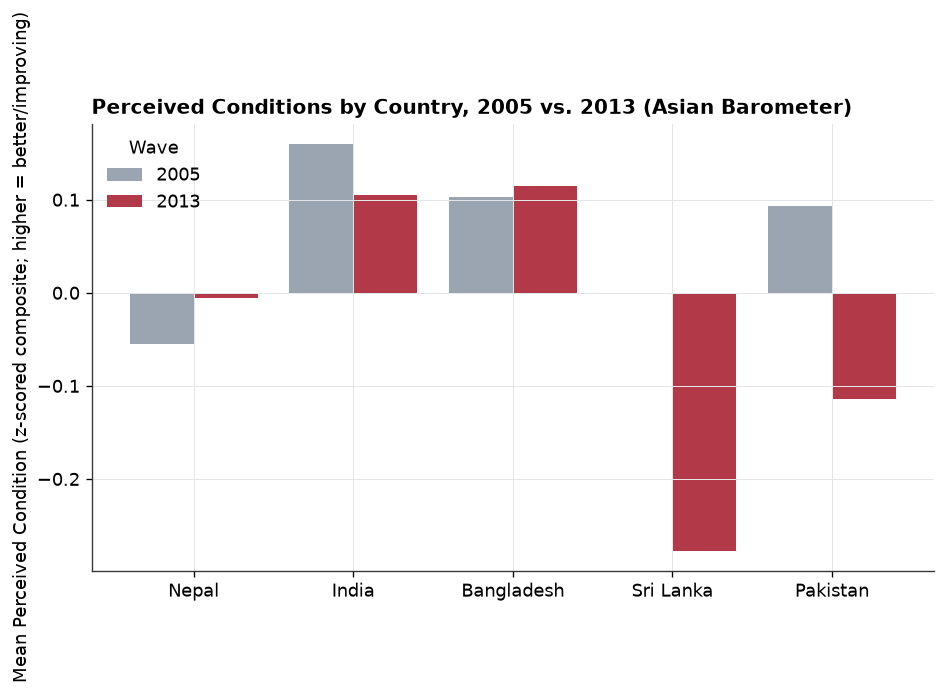

In [14]:
visualization.figure_abs_condition_wave(abs_df)
plt.show()

## ABS government problem-solving expectation (2013 only)
This study's closest empirical analog for Endsley's "projection" stage (Section 3.3).

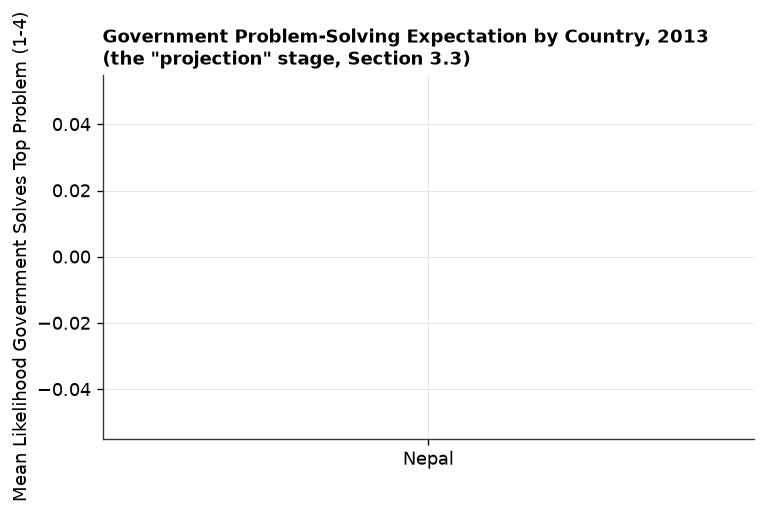

In [15]:
result = visualization.figure_abs_problem_solving_expectation(abs_df)
if result is not None:
    plt.show()

## Triangulation — ABS trust vs. WGI Government Effectiveness

Does ABS's individual-level aggregate trust track the expert-coded governance panel for the same country-years? A convergent-validity check (Section 3.3), not a forecast and not a substitute for either one.

19:59:49 [INFO] 1/10 country-wave rows had no matching GOV_WGI_GE value in the panel (dropped from the plot).


INFO:nepal_south_asia:1/10 country-wave rows had no matching GOV_WGI_GE value in the panel (dropped from the plot).


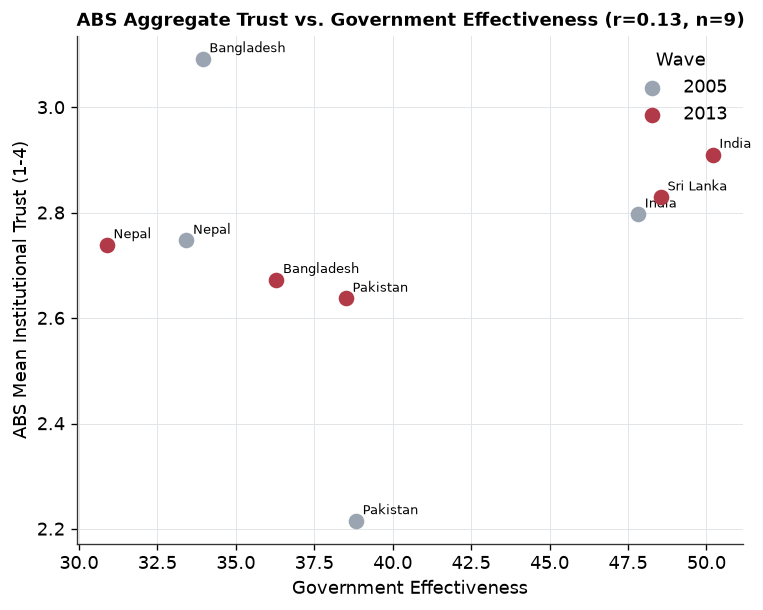

,country,wave,abs_trust,year,GOV_WGI_GE
0,Bangladesh,2005,3.092,2005,33.945
1,Bangladesh,2013,2.673,2013,36.293
2,India,2005,2.797,2005,47.822
3,India,2013,2.911,2013,50.199
4,Nepal,2005,2.747,2005,33.425
5,Nepal,2013,2.739,2013,30.889
6,Pakistan,2005,2.215,2005,38.830
7,Pakistan,2013,2.637,2013,38.507
8,Sri Lanka,2013,2.830,2013,48.546


In [16]:
fig_tri, merged_check = visualization.figure_triangulation(abs_df, panel)
if fig_tri is not None:
    plt.show()
    display(merged_check.round(3))

All figures are saved under `figures/` as matched PNG (300dpi) + PDF pairs.